<a href="https://vigneashpandiyan.github.io/publications/Codes/" target="_blank" rel="noopener noreferrer">
  <img src="https://vigneashpandiyan.github.io/images/Link.png"
       style="max-width: 800px; width: 100%; height: auto;">
</a>

# ResNET

ResNet (Residual Network) is a CNN architecture built around residual blocks that use skip connections (shortcuts) to make very deep networks trainable.

![https___substack-post-media.s3.amazonaws.com_public_images_efb26b8b-0058-42f4-a1aa-7ca96bfcb922_1854x871[1].png](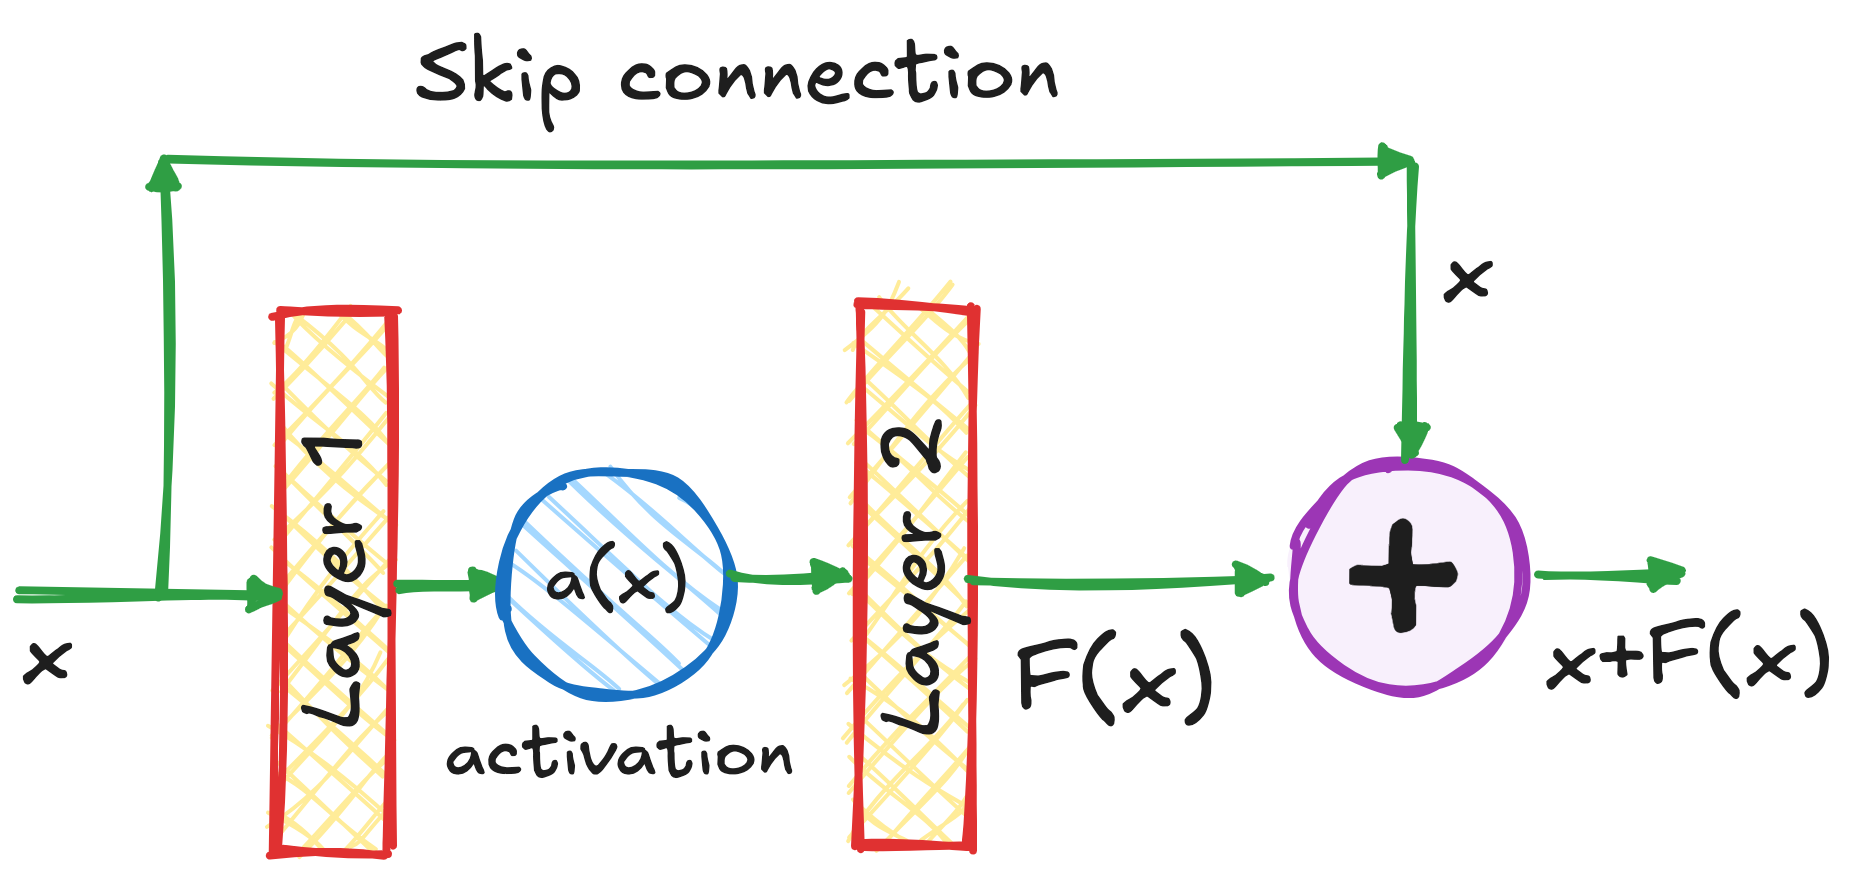)

We will define, train, evaluate, and visualize the performance of a simplified ResNet model with 3 basic blocks and a base channel count of 16 on the MNIST dataset.

## Loading the MNIST Dataset



In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 2. Define a transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 3. Download and load the MNIST training dataset
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
print("MNIST training dataset loaded successfully.")

# 4. Download and load the MNIST test dataset
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
print("MNIST test dataset loaded successfully.")

# 5. Create a DataLoader for the training dataset
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
print(f"Train DataLoader created with batch size 64 and {len(train_loader)} batches.")

# 6. Create a DataLoader for the test dataset
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
print(f"Test DataLoader created with batch size 1000 and {len(test_loader)} batches.")

# 7. Determine the device to use for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define a BasicBlock class
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if len(self.downsample) > 0:
            identity = self.downsample(x)

        out += identity
        out = F.relu(out)
        return out

# Define a SimpleResNet class
class SimpleResNet(nn.Module):
    def __init__(self, num_blocks, base_channels, num_classes=10):
        super(SimpleResNet, self).__init__()

        # Enforce the 16-filter limit
        if base_channels > 16:
            base_channels = 16
            print(f"Warning: base_channels adjusted to {base_channels} to respect the 16-filter limit.")

        self.in_channels = base_channels # Tracks current number of channels

        # Initial convolutional layer for MNIST (1 input channel)
        self.conv1 = nn.Conv2d(1, base_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(base_channels)
        self.relu = nn.ReLU(inplace=True)

        # Create a layer of BasicBlocks
        # All blocks will operate with `base_channels` (which is 16) due to the constraint.
        self.layer1 = self._make_layer(BasicBlock, base_channels, num_blocks, stride=1)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1)) # Global Average Pooling
        # Final fully connected layer
        self.fc = nn.Linear(base_channels * BasicBlock.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []
        # First block in the layer
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * block.expansion # Update in_channels for subsequent blocks

        # Remaining blocks with stride 1
        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels, 1))

        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

print("BasicBlock and SimpleResNet classes defined successfully.")

## Instantiating a Simple ResNet Model (3 blocks, 16 filters)



In [ ]:
simple_model = SimpleResNet(num_blocks=3, base_channels=16)
simple_model.to(device)
print(f"SimpleResNet model instantiated with 3 blocks and 16 base channels, and moved to {device}.")

## Defining Loss Function and Optimizer

Re-initializing the `optimizer` with the parameters of the newly created `simple_model` using `SGD` (Stochastic Gradient Descent) and `CrossEntropyLoss` as the criterion.


In [ ]:
import torch.optim as optim

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer with SGD, model parameters, learning rate, and momentum
optimizer = optim.SGD(simple_model.parameters(), lr=0.01, momentum=0.9)

print("Loss function (CrossEntropyLoss) and optimizer (SGD) defined successfully.")

## Summary of Simple ResNet Parameters



In [ ]:
from torchsummary import summary

# Display the model summary
summary(simple_model, input_size=(1, 28, 28))


## Training Simple ResNet Model




In [ ]:
train_losses = []
train_accuracies = []
num_epochs = 10

print("Starting training...")

for epoch in range(num_epochs):
    simple_model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = simple_model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct_predictions / total_samples

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

print("Training finished.")

## Save the Trained Simple Model


We save the trained simple ResNet model's state dictionary to a file. This allows the model to be reloaded later without needing to retrain.


In [ ]:
model_save_path = 'simple_resnet_mnist.pth'
torch.save(simple_model.state_dict(), model_save_path)
print(f"Simple ResNet model state dictionary saved to {model_save_path}")

## Loading Simple Model


We load the previously saved simple ResNet model's state dictionary into a new instance of the `SimpleResNet` model, ensuring it's ready for evaluation or further use without retraining.


In [ ]:
loaded_simple_model = SimpleResNet(num_blocks=3, base_channels=16)
loaded_simple_model.load_state_dict(torch.load(model_save_path))
loaded_simple_model.to(device)
print(f"Simple ResNet model loaded from {model_save_path} and moved to {device}.")

## Testing Simple Model


In [ ]:
print("Starting evaluation of the loaded model...")

loaded_simple_model.eval() # Set the model to evaluation mode
test_loss = 0
correct_predictions = 0
total_samples = 0

with torch.no_grad(): # Disable gradient calculation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = loaded_simple_model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

test_loss /= len(test_loader) # Calculate average test loss
test_accuracy = 100 * correct_predictions / total_samples # Calculate test accuracy

print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')
print("Evaluation finished.")

## Plotting Training Curves


We plot the training loss and accuracy curves over epochs for the simple ResNet model to visualize its learning progress and identify potential overfitting or underfitting.


In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Subplot 1: Training Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(False)

# Subplot 2: Training Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy Over Epochs')
plt.legend()
plt.grid(False)

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()

# Display the plots
plt.show()

print("Training loss and accuracy curves plotted successfully.")

## Generating Confusion Matrix


This will provide a detailed visualization of true versus predicted labels, helping to identify specific classes where the model might be performing well or poorly.


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Initialize lists to store true and predicted labels
all_labels = []
all_predictions = []

# Set the model to evaluation mode
loaded_simple_model.eval()

# Disable gradient calculations
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = loaded_simple_model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Convert lists to numpy arrays
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Simple ResNet on MNIST Test Set')
plt.show()

print("Confusion matrix generated and displayed successfully.")